In [31]:
import sys, os
from pathlib import Path
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

PROJECT_PATH = Path(r"B:\College\DL\handwriting_autocomplete_system\phase3_style_transfer")
os.chdir(PROJECT_PATH)
sys.path.insert(0, str(PROJECT_PATH))

from lib.utils import yaml2config
from lib.alphabet import strLabelConverter
from networks.BigGAN_networks import Generator
from networks.module import StyleEncoder, StyleBackbone

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT = PROJECT_PATH / 'server_files' / 'epoch_70.pth'
PRETRAINED_WID = PROJECT_PATH / 'pretrained' / 'wid_iam_new.pth'
IMG_HEIGHT, CHAR_WIDTH = 64, 32
print(f"Device: {DEVICE}")

Device: cuda


In [32]:
# Load models
cfg = yaml2config(str(PROJECT_PATH / 'configs' / 'gan_iam.yml'))
generator = Generator(**cfg.GenModel).to(DEVICE)
style_backbone = StyleBackbone(**cfg.StyBackbone).to(DEVICE)
style_encoder = StyleEncoder(**cfg.EncModel).to(DEVICE)

# Load weights
ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
generator.load_state_dict(ckpt['generator'])
style_encoder.load_state_dict(ckpt['style_encoder'])
if PRETRAINED_WID.exists():
    style_backbone.load_state_dict(torch.load(PRETRAINED_WID, map_location=DEVICE)['StyleBackbone'])

generator.eval(); style_encoder.eval(); style_backbone.eval()
label_converter = strLabelConverter('_'.join(cfg.dataset.split('_')[:2]))
print(f"Models loaded (epoch {ckpt.get('epoch', 'N/A')})")

Models loaded (epoch 70)


In [33]:
def preprocess(img_path):
    """Load and preprocess image for style extraction."""
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    h, w = img.shape
    new_w = max(int(w * IMG_HEIGHT / h), CHAR_WIDTH * 2)
    new_w = new_w + (CHAR_WIDTH - new_w % CHAR_WIDTH) % CHAR_WIDTH
    img = cv2.resize(img, (new_w, IMG_HEIGHT), interpolation=cv2.INTER_AREA if new_w < w else cv2.INTER_LINEAR)
    if img.mean() > 127: img = 255 - img  # Invert if light background
    tensor = torch.from_numpy((img / 255.0 - 0.5) / 0.5).float().unsqueeze(0).unsqueeze(0)
    return tensor, new_w

def to_image(tensor):
    """Convert tensor to displayable image."""
    img = tensor.squeeze().cpu().numpy()
    return np.clip((1 - (img + 1) / 2) * 255, 0, 255).astype(np.uint8)

@torch.no_grad()
def generate(style_img_path, texts):
    """Generate handwriting with given style and texts."""
    img_tensor, width = preprocess(style_img_path)
    img_tensor = img_tensor.to(DEVICE)
    style = style_encoder(img_tensor, torch.tensor([width]).to(DEVICE), style_backbone, vae_mode=False)
    
    results = []
    for text in texts:
        lbs, lb_lens = label_converter.encode([text])
        fake = generator(style, lbs.to(DEVICE), lb_lens.to(DEVICE))
        results.append((text, to_image(fake)))
    return results

In [34]:
# === Generate ===
STYLE_IMAGE = PROJECT_PATH / 'inference' / 'input' / 'sample.png'  # Your style reference
TEXTS = ['hello', 'world', 'python', 'neural', 'network']

if STYLE_IMAGE.exists():
    results = generate(STYLE_IMAGE, TEXTS)
    
    fig, axes = plt.subplots(len(results) + 1, 1, figsize=(12, 2 * (len(results) + 1)))
    ref = cv2.imread(str(STYLE_IMAGE), cv2.IMREAD_GRAYSCALE)
    axes[0].imshow(ref, cmap='gray'); axes[0].set_title('Reference Style'); axes[0].axis('off')
    
    for i, (text, img) in enumerate(results):
        axes[i+1].imshow(img, cmap='gray'); axes[i+1].set_title(f'"{text}"'); axes[i+1].axis('off')
    
    plt.tight_layout(); plt.show()
else:
    print(f"Put a style reference image at: {STYLE_IMAGE}")

Put a style reference image at: B:\College\DL\handwriting_autocomplete_system\phase3_style_transfer\inference\input\sample.png


In [35]:
# === Batch process all images in input folder ===
INPUT_DIR = PROJECT_PATH / 'inference' / 'input'
OUTPUT_DIR = PROJECT_PATH / 'inference' / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for img_path in INPUT_DIR.glob('*.png'):
    results = generate(img_path, TEXTS)
    
    fig, axes = plt.subplots(1, len(results), figsize=(3 * len(results), 2))
    for i, (text, img) in enumerate(results):
        axes[i].imshow(img, cmap='gray'); axes[i].set_title(text); axes[i].axis('off')
    
    plt.savefig(OUTPUT_DIR / f'{img_path.stem}_generated.png', dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Processed: {img_path.name}")

print(f"Done! Results in {OUTPUT_DIR}")

Processed: image.png
Processed: jumps.png
Processed: jumps.png
Processed: Screenshot 2025-11-26 232829.png
Done! Results in B:\College\DL\handwriting_autocomplete_system\phase3_style_transfer\inference\output
Processed: Screenshot 2025-11-26 232829.png
Done! Results in B:\College\DL\handwriting_autocomplete_system\phase3_style_transfer\inference\output


## Loss Plots from Training History

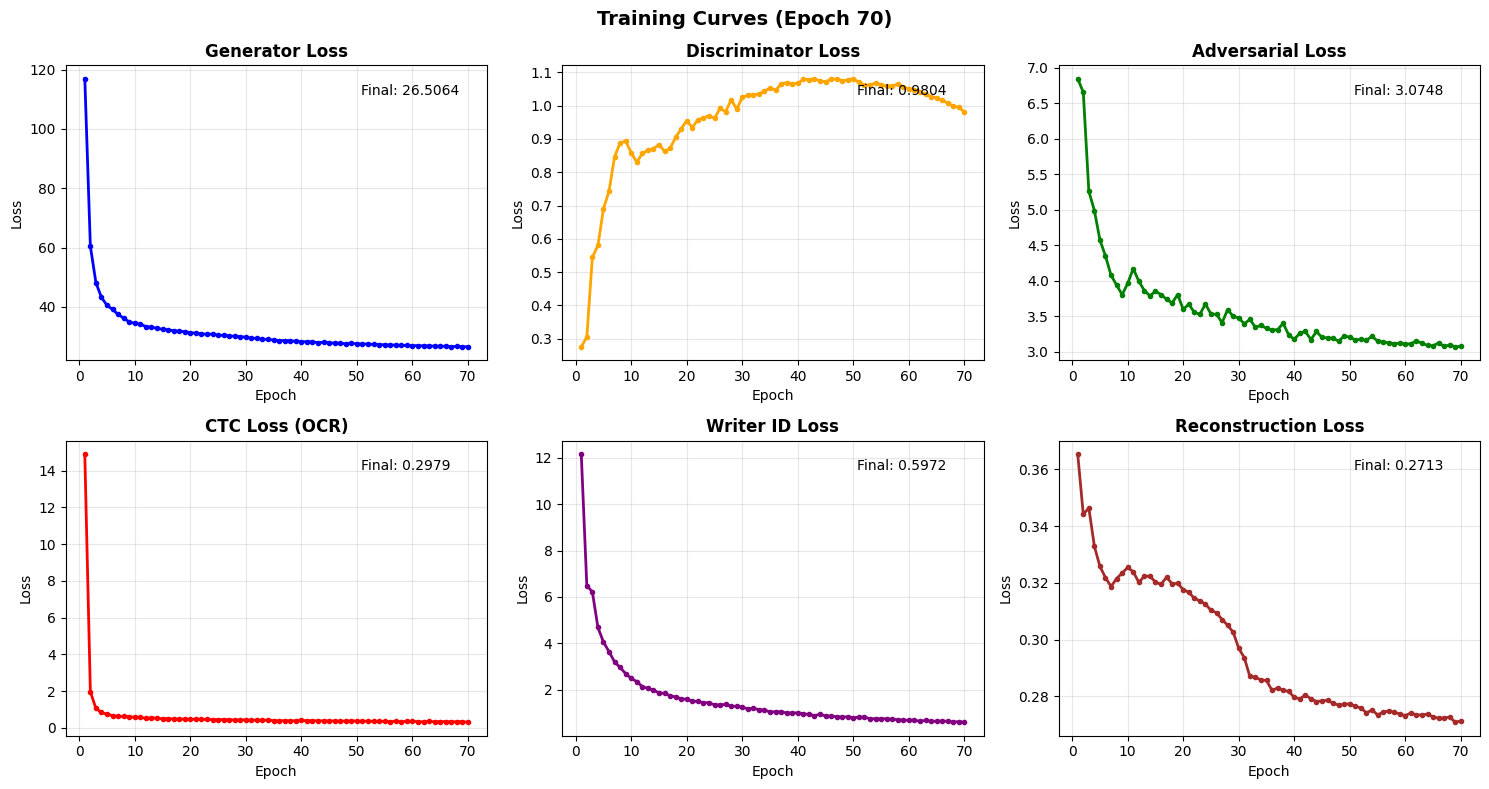

Loss curves saved to loss_curves.png


In [36]:
# Plot training losses from checkpoint
history = ckpt.get('history', {})
if history and history.get('epoch'):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    plots = [
        ('g_loss', 'Generator Loss', 'blue'),
        ('d_loss', 'Discriminator Loss', 'orange'),
        ('adv_loss', 'Adversarial Loss', 'green'),
        ('ctc_loss', 'CTC Loss (OCR)', 'red'),
        ('wid_loss', 'Writer ID Loss', 'purple'),
        ('recn_loss', 'Reconstruction Loss', 'brown')
    ]
    
    for ax, (key, title, color) in zip(axes.ravel(), plots):
        if key in history and history[key]:
            ax.plot(history['epoch'], history[key], color=color, linewidth=2, marker='o', markersize=3)
            ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
            ax.set_title(title, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.annotate(f'Final: {history[key][-1]:.4f}', xy=(0.7, 0.9), xycoords='axes fraction')
    
    plt.suptitle(f'Training Curves (Epoch {ckpt.get("epoch", "N/A")})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROJECT_PATH / 'loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Loss curves saved to loss_curves.png")
else:
    print("No training history in checkpoint")

## Inference on Original Dataset

In [37]:
# Load test dataset and generate reconstructions
from lib.datasets import get_dataset, get_collect_fn
from torch.utils.data import DataLoader
from networks.module import Recognizer, WriterIdentifier

# Load test set
collect_fn = get_collect_fn(cfg.training.sort_input, sort_style=True)
test_dataset = get_dataset(cfg.valid.dset_name, cfg.valid.dset_split, recogn_aug=False, wid_aug=False, process_style=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collect_fn, num_workers=0)
print(f"Test samples: {len(test_dataset)}")

# Load recognizer for CER/WER
recognizer = Recognizer(**cfg.OcrModel).to(DEVICE)
if (PROJECT_PATH / cfg.training.pretrained_r).exists():
    recognizer.load_state_dict(torch.load(PROJECT_PATH / cfg.training.pretrained_r, map_location=DEVICE)['Recognizer'])
recognizer.eval()

# Load writer identifier
writer_id = WriterIdentifier(**cfg.WidModel).to(DEVICE)
if PRETRAINED_WID.exists():
    writer_id.load_state_dict(torch.load(PRETRAINED_WID, map_location=DEVICE)['WriterIdentifier'])
writer_id.eval()
print("Auxiliary models loaded")

Test samples: 11170
Auxiliary models loaded


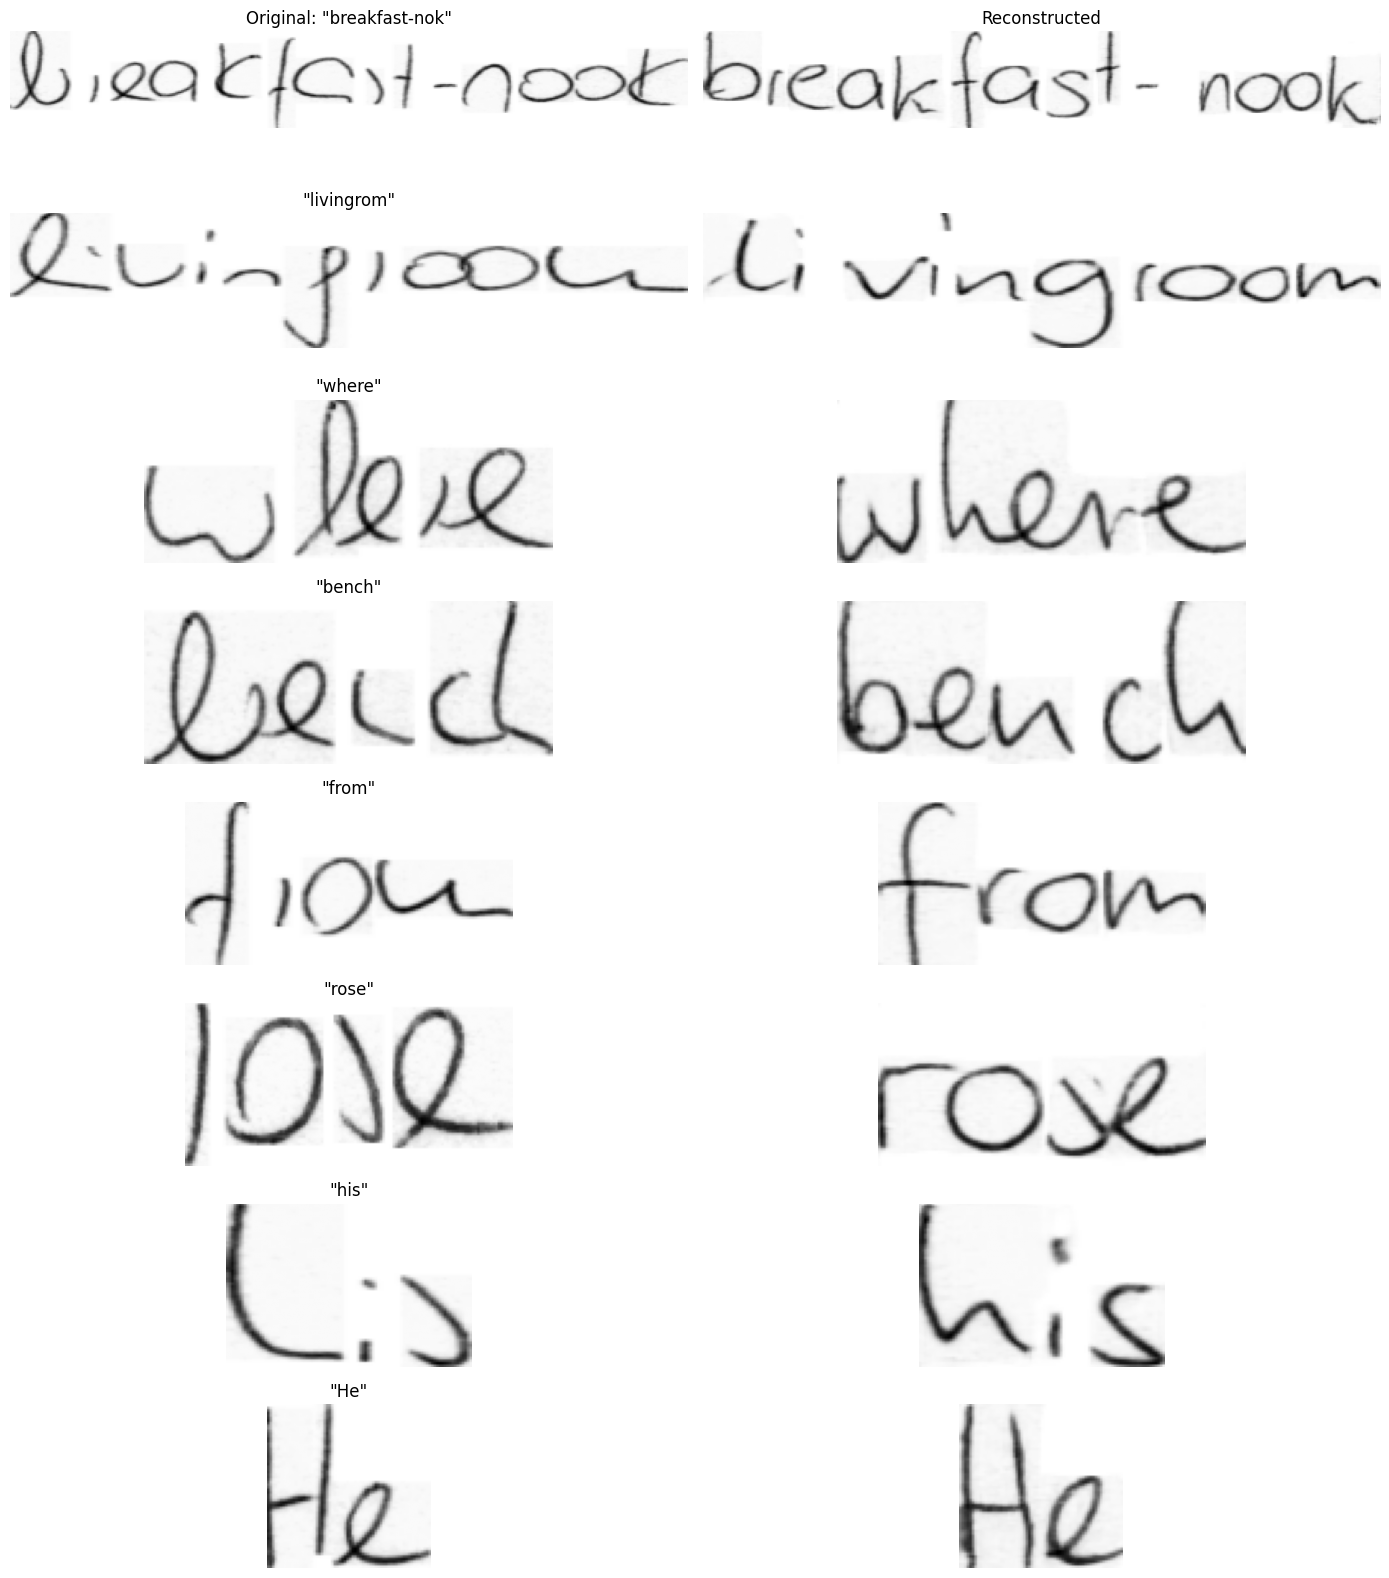

In [38]:
# Generate reconstructions on test set and visualize samples
@torch.no_grad()
def generate_reconstructions(loader, n_samples=8):
    """Generate reconstructed images from test set."""
    batch = next(iter(loader))
    real_imgs = batch['style_imgs'].to(DEVICE)
    real_img_lens = batch['style_img_lens'].to(DEVICE)
    real_lbs = batch['lbs'].to(DEVICE)
    real_lb_lens = batch['lb_lens'].to(DEVICE)
    
    # Encode style and reconstruct
    enc_z = style_encoder(real_imgs, real_img_lens, style_backbone, vae_mode=False)
    recn_imgs = generator(enc_z, real_lbs, real_lb_lens)
    
    # Decode labels
    texts = label_converter.decode(real_lbs.cpu(), real_lb_lens.cpu())
    
    return real_imgs[:n_samples], recn_imgs[:n_samples], real_img_lens[:n_samples], texts[:n_samples]

real, recon, lens, texts = generate_reconstructions(test_loader)

# Visualize
fig, axes = plt.subplots(min(8, len(real)), 2, figsize=(14, 2*min(8, len(real))))
for i in range(min(8, len(real))):
    w = lens[i].item()
    # Original
    orig = ((real[i, 0, :, :w].cpu().numpy() + 1) / 2)
    axes[i, 0].imshow(1 - orig, cmap='gray'); axes[i, 0].axis('off')
    axes[i, 0].set_title(f'Original: "{texts[i]}"' if i == 0 else f'"{texts[i]}"')
    # Reconstructed
    rec = ((recon[i, 0, :, :w].cpu().numpy() + 1) / 2)
    axes[i, 1].imshow(1 - rec, cmap='gray'); axes[i, 1].axis('off')
    axes[i, 1].set_title('Reconstructed' if i == 0 else '')

plt.tight_layout()
plt.savefig(PROJECT_PATH / 'reconstruction_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Metrics Calculation (FID, KID, IS, CER, WER, WIER, MSSIM, PSNR)

In [39]:
# CER, WER, WIER calculation
from collections import defaultdict
import editdistance
from tqdm import tqdm

@torch.no_grad()
def calculate_ocr_metrics(loader, max_batches=50):
    """Calculate CER, WER, WIER on reconstructed images."""
    total_chars, total_words, total_writers = 0, 0, 0
    char_errors, word_errors, writer_errors = 0, 0, 0
    ctc_len_scale = recognizer.len_scale
    
    for i, batch in enumerate(tqdm(loader, total=min(max_batches, len(loader)), desc="OCR Metrics")):
        if i >= max_batches: break
        
        real_imgs = batch['style_imgs'].to(DEVICE)
        real_img_lens = batch['style_img_lens'].to(DEVICE)
        real_lbs = batch['lbs'].to(DEVICE)
        real_lb_lens = batch['lb_lens'].to(DEVICE)
        real_wids = batch['wids'].to(DEVICE)
        
        # Generate reconstructions
        enc_z = style_encoder(real_imgs, real_img_lens, style_backbone, vae_mode=False)
        recn_imgs = generator(enc_z, real_lbs, real_lb_lens)
        recn_img_lens = real_lb_lens * cfg.char_width
        
        # OCR on reconstructed images
        ocr_out = recognizer(recn_imgs, recn_img_lens)
        _, preds = ocr_out.max(2)
        preds = preds.transpose(1, 0).contiguous()  # (B, T)
        
        # Decode ground truth
        gt_texts = label_converter.decode(real_lbs.cpu(), real_lb_lens.cpu())
        
        # Decode CTC predictions manually (handle blanks and repeated chars)
        pred_texts = []
        for b in range(preds.size(0)):
            pred_seq = preds[b].cpu().tolist()
            # CTC decode: remove blanks (0) and consecutive duplicates
            decoded = []
            prev = -1
            for idx in pred_seq:
                if idx != 0 and idx != prev:  # 0 is blank token
                    decoded.append(idx)
                prev = idx
            # Convert indices to string
            if decoded:
                text = ''.join([label_converter.alphabet[c - 1] for c in decoded if c > 0 and c <= len(label_converter.alphabet)])
            else:
                text = ''
            pred_texts.append(text)
        
        for pred, gt in zip(pred_texts, gt_texts):
            pred, gt = pred.strip(), gt.strip()
            total_chars += len(gt)
            total_words += 1
            char_errors += editdistance.eval(pred, gt)
            if pred != gt:
                word_errors += 1
        
        # Writer ID on reconstructed images
        wid_logits = writer_id(recn_imgs, recn_img_lens, style_backbone)
        wid_preds = wid_logits.argmax(dim=1)
        total_writers += len(real_wids)
        writer_errors += (wid_preds != real_wids).sum().item()
    
    cer = char_errors / max(total_chars, 1) * 100
    wer = word_errors / max(total_words, 1) * 100
    wier = writer_errors / max(total_writers, 1) * 100
    
    return {'CER': cer, 'WER': wer, 'WIER': wier}

ocr_metrics = calculate_ocr_metrics(test_loader)
print(f"\n=== OCR & Writer ID Metrics ===")
print(f"CER:  {ocr_metrics['CER']:.2f}%")
print(f"WER:  {ocr_metrics['WER']:.2f}%")
print(f"WIER: {ocr_metrics['WIER']:.2f}%")

OCR Metrics: 100%|██████████| 50/50 [00:02<00:00, 22.43it/s]


=== OCR & Writer ID Metrics ===
CER:  116.20%
WER:  100.00%
WIER: 98.00%


In [40]:
# MSSIM and PSNR calculation
from skimage import metrics as skmetrics

@torch.no_grad()
def calculate_mssim_psnr(loader, max_batches=50):
    """Calculate MSSIM and PSNR between original and reconstructed images."""
    psnr_scores, mssim_scores = [], []
    
    for i, batch in enumerate(tqdm(loader, total=min(max_batches, len(loader)), desc="MSSIM/PSNR")):
        if i >= max_batches: break
        
        real_imgs = batch['style_imgs'].to(DEVICE)
        real_img_lens = batch['style_img_lens'].to(DEVICE)
        real_lbs = batch['lbs'].to(DEVICE)
        real_lb_lens = batch['lb_lens'].to(DEVICE)
        
        # Generate reconstructions
        enc_z = style_encoder(real_imgs, real_img_lens, style_backbone, vae_mode=False)
        recn_imgs = generator(enc_z, real_lbs, real_lb_lens)
        
        for j in range(real_imgs.size(0)):
            w = min(real_img_lens[j].item(), recn_imgs.size(-1))
            orig = ((real_imgs[j, 0, :, :w].cpu().numpy() + 1) / 2).astype(np.float32)
            recon = ((recn_imgs[j, 0, :, :w].cpu().numpy() + 1) / 2).astype(np.float32)
            
            # PSNR
            psnr_scores.append(skmetrics.peak_signal_noise_ratio(orig, recon, data_range=1.0))
            
            # MSSIM (adaptive window size)
            h, w_img = orig.shape
            win = min(h, w_img)
            if win % 2 == 0: win -= 1
            win = max(3, min(win, 7))
            mssim_scores.append(skmetrics.structural_similarity(orig, recon, data_range=1.0, win_size=win))
    
    return {'MSSIM': np.mean(mssim_scores), 'PSNR': np.mean(psnr_scores)}

quality_metrics = calculate_mssim_psnr(test_loader)
print(f"\n=== Image Quality Metrics ===")
print(f"MSSIM: {quality_metrics['MSSIM']:.4f}")
print(f"PSNR:  {quality_metrics['PSNR']:.2f} dB")

MSSIM/PSNR: 100%|██████████| 50/50 [00:01<00:00, 26.43it/s]


=== Image Quality Metrics ===
MSSIM: 0.3230
PSNR:  14.02 dB


In [41]:
# FID, KID, Inception Score calculation
from scipy import linalg
from torch.nn.functional import adaptive_avg_pool2d
from sklearn.metrics.pairwise import polynomial_kernel
from scipy.stats import entropy

try:
    from metric.inception import InceptionV3
    HAS_INCEPTION = True
except:
    HAS_INCEPTION = False
    print("InceptionV3 not available, skipping FID/KID/IS")

@torch.no_grad()
def calculate_fid_kid_is(loader, max_batches=50):
    """Calculate FID, KID, and Inception Score."""
    if not HAS_INCEPTION:
        return {'FID': None, 'KID': None, 'IS_real': None, 'IS_gen': None}
    
    # Load InceptionV3
    block_idx = InceptionV3.BLOCK_INDEX_BY_DIM[2048]
    inception = InceptionV3([block_idx]).to(DEVICE).eval()
    
    real_acts, gen_acts = [], []
    real_logits, gen_logits = [], []
    
    for i, batch in enumerate(tqdm(loader, total=min(max_batches, len(loader)), desc="FID/KID/IS")):
        if i >= max_batches: break
        
        real_imgs = batch['style_imgs'].to(DEVICE)
        real_img_lens = batch['style_img_lens'].to(DEVICE)
        real_lbs = batch['lbs'].to(DEVICE)
        real_lb_lens = batch['lb_lens'].to(DEVICE)
        
        # Generate reconstructions
        enc_z = style_encoder(real_imgs, real_img_lens, style_backbone, vae_mode=False)
        gen_imgs = generator(enc_z, real_lbs, real_lb_lens)
        
        # Prepare for Inception (normalize to [0,1], 3 channels)
        real_in = ((real_imgs + 1) / 2).repeat(1, 3, 1, 1)
        gen_in = ((gen_imgs + 1) / 2).repeat(1, 3, 1, 1)
        
        # Get activations
        real_feat, real_log = inception(real_in, real_img_lens // real_imgs.size(-2))
        gen_feat, gen_log = inception(gen_in, real_lb_lens * cfg.char_width // gen_imgs.size(-2))
        
        if real_feat.dim() > 2:
            real_feat = adaptive_avg_pool2d(real_feat, (1, 1)).flatten(1)
            gen_feat = adaptive_avg_pool2d(gen_feat, (1, 1)).flatten(1)
        
        real_acts.append(real_feat.cpu().numpy())
        gen_acts.append(gen_feat.cpu().numpy())
        real_logits.append(real_log.cpu().numpy())
        gen_logits.append(gen_log.cpu().numpy())
    
    real_acts = np.concatenate(real_acts, axis=0)
    gen_acts = np.concatenate(gen_acts, axis=0)
    real_logits = np.concatenate(real_logits, axis=0)
    gen_logits = np.concatenate(gen_logits, axis=0)
    
    # FID
    mu1, sigma1 = real_acts.mean(0), np.cov(real_acts, rowvar=False)
    mu2, sigma2 = gen_acts.mean(0), np.cov(gen_acts, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)
    
    # KID (simplified)
    n = min(1000, len(real_acts), len(gen_acts))
    idx_r, idx_g = np.random.choice(len(real_acts), n, replace=False), np.random.choice(len(gen_acts), n, replace=False)
    K_rr = polynomial_kernel(real_acts[idx_r], degree=3)
    K_gg = polynomial_kernel(gen_acts[idx_g], degree=3)
    K_rg = polynomial_kernel(real_acts[idx_r], gen_acts[idx_g], degree=3)
    kid = (K_rr.mean() + K_gg.mean() - 2 * K_rg.mean()) * 100
    
    # Inception Score
    def calc_is(logits):
        py = np.mean(logits, axis=0)
        scores = [entropy(logits[i], py) for i in range(len(logits))]
        return np.exp(np.mean(scores))
    
    is_real, is_gen = calc_is(real_logits), calc_is(gen_logits)
    
    return {'FID': fid, 'KID': kid, 'IS_real': is_real, 'IS_gen': is_gen}

fid_metrics = calculate_fid_kid_is(test_loader)
print(f"\n=== Generative Metrics ===")
if fid_metrics['FID'] is not None:
    print(f"FID:     {fid_metrics['FID']:.2f}")
    print(f"KID:     {fid_metrics['KID']:.4f}")
    print(f"IS (real): {fid_metrics['IS_real']:.2f}")
    print(f"IS (gen):  {fid_metrics['IS_gen']:.2f}")

c:\Users\PC\miniconda3\envs\dl_pro\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\PC\miniconda3\envs\dl_pro\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
FID/KID/IS: 100%|██████████| 50/50 [00:10<00:00,  4.79it/s]

C:\Users\PC\AppData\Local\Temp\ipykernel_61216\2953875890.py:65: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
C:\Users\PC\AppData\Local\Temp\ipykernel_61216\2953875890.py:65: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigm


=== Generative Metrics ===
FID:     26.59
KID:     0.7720
IS (real): 1.63
IS (gen):  1.68


In [42]:
# Summary of all metrics
print("\n" + "="*50)
print("          EVALUATION SUMMARY")
print("="*50)
print(f"Checkpoint: Epoch {ckpt.get('epoch', 'N/A')}")
print("-"*50)
print("OCR & Writer ID:")
print(f"  CER:   {ocr_metrics['CER']:.2f}%")
print(f"  WER:   {ocr_metrics['WER']:.2f}%")
print(f"  WIER:  {ocr_metrics['WIER']:.2f}%")
print("-"*50)
print("Image Quality:")
print(f"  MSSIM: {quality_metrics['MSSIM']:.4f}")
print(f"  PSNR:  {quality_metrics['PSNR']:.2f} dB")
print("-"*50)
if fid_metrics['FID'] is not None:
    print("Generative Quality:")
    print(f"  FID:   {fid_metrics['FID']:.2f}")
    print(f"  KID:   {fid_metrics['KID']:.4f}")
    print(f"  IS:    {fid_metrics['IS_gen']:.2f}")
print("="*50)

# Save metrics to file
metrics_summary = {**ocr_metrics, **quality_metrics, **fid_metrics, 'epoch': ckpt.get('epoch', 0)}
import json
with open(PROJECT_PATH / 'evaluation_metrics.json', 'w') as f:
    json.dump({k: float(v) if v is not None else None for k, v in metrics_summary.items()}, f, indent=2)
print(f"\nMetrics saved to evaluation_metrics.json")


          EVALUATION SUMMARY
Checkpoint: Epoch 70
--------------------------------------------------
OCR & Writer ID:
  CER:   116.20%
  WER:   100.00%
  WIER:  98.00%
--------------------------------------------------
Image Quality:
  MSSIM: 0.3230
  PSNR:  14.02 dB
--------------------------------------------------
Generative Quality:
  FID:   26.59
  KID:   0.7720
  IS:    1.68

Metrics saved to evaluation_metrics.json


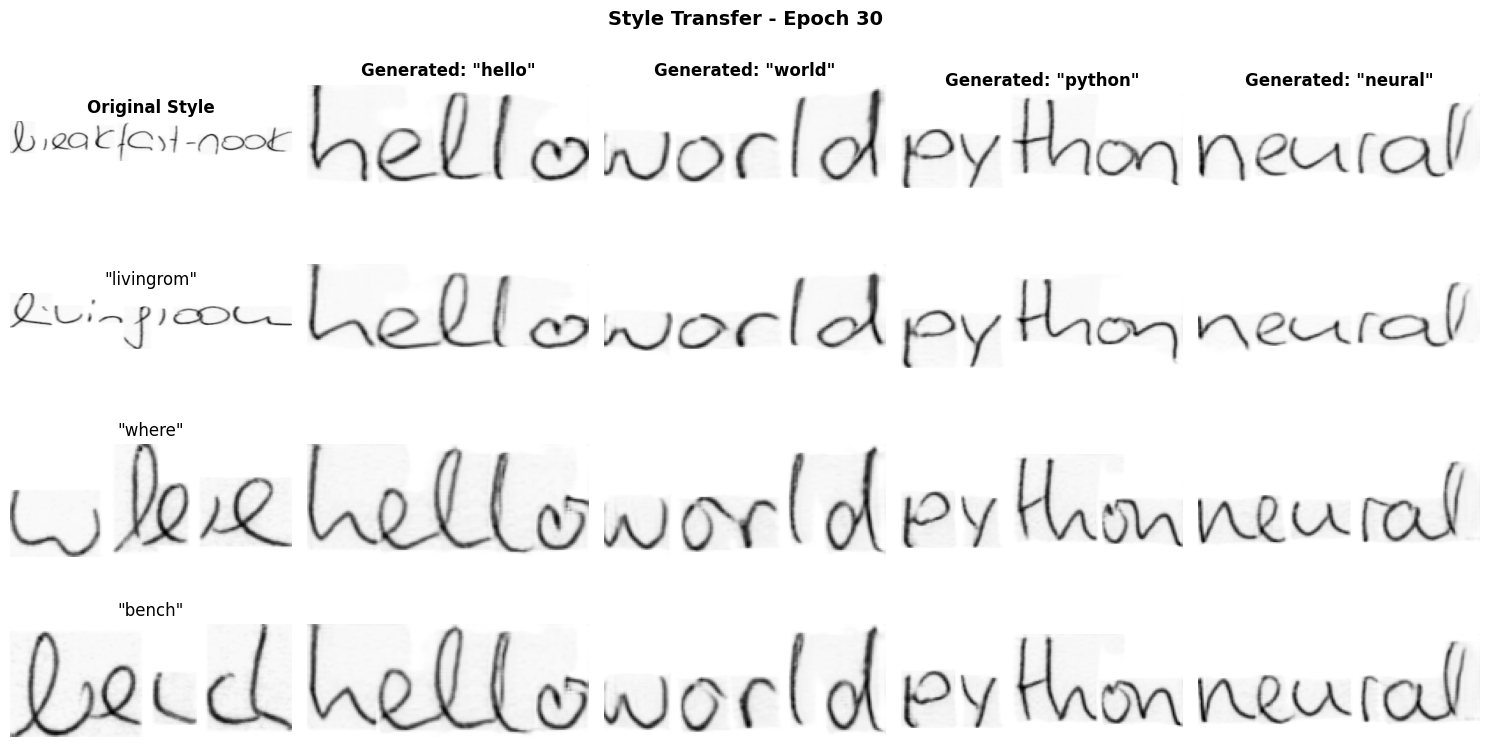

Saved to batch_generation_samples.png


In [ ]:
# Generate samples over a batch from test set with different target texts
@torch.no_grad()
def generate_batch_samples(loader, target_texts=['hello', 'world', 'test', 'write'], n_styles=4):
    """Generate images using styles from test set with custom target texts."""
    batch = next(iter(loader))
    real_imgs = batch['style_imgs'].to(DEVICE)[:n_styles]
    real_img_lens = batch['style_img_lens'].to(DEVICE)[:n_styles]
    original_lbs = batch['lbs'].to(DEVICE)[:n_styles]
    original_lb_lens = batch['lb_lens'].to(DEVICE)[:n_styles]
    
    # Get original texts
    original_texts = label_converter.decode(original_lbs.cpu(), original_lb_lens.cpu())
    
    # Extract styles
    styles = style_encoder(real_imgs, real_img_lens, style_backbone, vae_mode=False)
    
    results = []
    for i in range(n_styles):
        style_i = styles[i:i+1]  # Single style
        w = real_img_lens[i].item()
        
        # Original image
        orig_img = ((real_imgs[i, 0, :, :w].cpu().numpy() + 1) / 2)
        
        # Generate with different texts
        generated = []
        for text in target_texts:
            lbs, lb_lens = label_converter.encode([text])
            fake = generator(style_i, lbs.to(DEVICE), lb_lens.to(DEVICE))
            gen_img = ((fake[0, 0].cpu().numpy() + 1) / 2)
            generated.append((text, gen_img))
        
        results.append({
            'original': orig_img,
            'original_text': original_texts[i],
            'generated': generated
        })
    
    return results

# Generate and visualize
TARGET_TEXTS = ['hello', 'world', 'python', 'neural']
results = generate_batch_samples(test_loader, target_texts=TARGET_TEXTS, n_styles=4)

# Plot: rows = styles, cols = original + generated texts
n_cols = 1 + len(TARGET_TEXTS)
n_rows = len(results)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 2 * n_rows))

for i, res in enumerate(results):
    # Original
    axes[i, 0].imshow(1 - res['original'], cmap='gray')
    axes[i, 0].set_title(f'Style: "{res["original_text"]}"' if i == 0 else f'"{res["original_text"]}"')
    axes[i, 0].axis('off')
    
    # Generated
    for j, (text, img) in enumerate(res['generated']):
        axes[i, j+1].imshow(1 - img, cmap='gray')
        axes[i, j+1].set_title(f'"{text}"' if i == 0 else '')
        axes[i, j+1].axis('off')

# Add row/col labels
axes[0, 0].set_title('Original Style', fontweight='bold')
for j, text in enumerate(TARGET_TEXTS):
    axes[0, j+1].set_title(f'Generated: "{text}"', fontweight='bold')

plt.suptitle(f'Style Transfer - Epoch {ckpt.get("epoch", "N/A")}', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig(PROJECT_PATH / 'batch_generation_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to batch_generation_samples.png")

Creating style interpolation GIF...
Text: 'Deep Learning Is Fun'
This may take a moment...

✓ GIF saved to: B:\College\DL\handwriting_autocomplete_system\phase3_style_transfer\inference\style_interpolation.gif
  Total frames: 120
  Duration: 4.0 seconds (fast loop!)

✓ GIF saved to: B:\College\DL\handwriting_autocomplete_system\phase3_style_transfer\inference\style_interpolation.gif
  Total frames: 120
  Duration: 4.0 seconds (fast loop!)


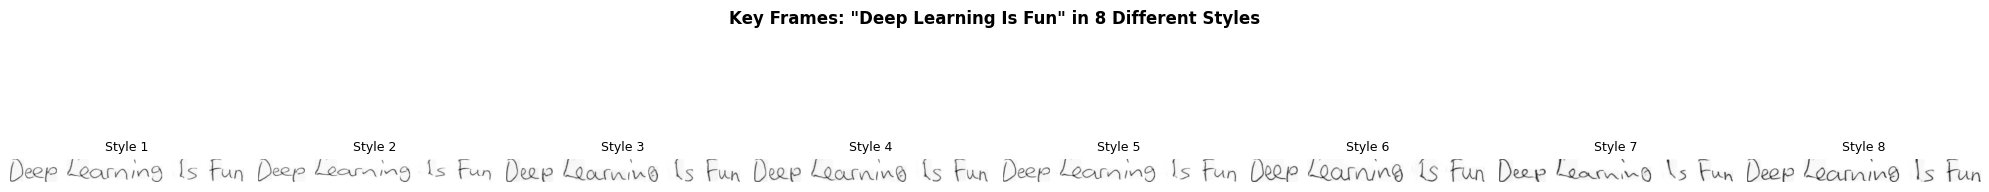

Key frames saved to style_interpolation_keyframes.png


In [30]:
# Style interpolation GIF - smoothly morph between different writing styles
from PIL import Image
import imageio

@torch.no_grad()
def create_style_interpolation_gif(loader, text="DEEP LEARNING IS FUN", n_styles=8, n_frames=15, fps=30):
    """Create a GIF showing smooth interpolation between different writing styles."""
    
    # Get multiple style samples from test set
    batch = next(iter(loader))
    real_imgs = batch['style_imgs'].to(DEVICE)[:n_styles]
    real_img_lens = batch['style_img_lens'].to(DEVICE)[:n_styles]
    
    # Extract style vectors
    styles = style_encoder(real_imgs, real_img_lens, style_backbone, vae_mode=False)
    
    # Encode target text
    lbs, lb_lens = label_converter.encode([text])
    lbs, lb_lens = lbs.to(DEVICE), lb_lens.to(DEVICE)
    
    frames = []
    
    # Interpolate between consecutive styles (loop back to first)
    for style_idx in range(n_styles):
        next_idx = (style_idx + 1) % n_styles
        style_a = styles[style_idx:style_idx+1]
        style_b = styles[next_idx:next_idx+1]
        
        for frame in range(n_frames):
            # Smooth easing interpolation (ease in-out)
            t = frame / n_frames
            alpha = t * t * (3 - 2 * t)  # Smoothstep
            interpolated_style = (1 - alpha) * style_a + alpha * style_b
            
            # Generate image
            fake = generator(interpolated_style, lbs, lb_lens)
            img = ((fake[0, 0].detach().cpu().numpy() + 1) / 2)
            img = (1 - img) * 255  # Invert for white background
            img = np.clip(img, 0, 255).astype(np.uint8)
            
            # Add text label and frame info
            h, w = img.shape
            # Pad image for labels
            padded = np.ones((h + 40, w, 3), dtype=np.uint8) * 255
            padded[20:20+h, :, :] = np.stack([img]*3, axis=-1)
            
            frames.append(padded)
    
    # Save as GIF
    gif_path = PROJECT_PATH / 'inference/style_interpolation.gif'
    imageio.mimsave(str(gif_path), frames, fps=fps, loop=0)
    
    return gif_path, len(frames)

# Create the interpolation GIF
print("Creating style interpolation GIF...")
print(f"Text: 'Deep Learning Is Fun'")
print("This may take a moment...")

gif_path, total_frames = create_style_interpolation_gif(
    test_loader, 
    text="Deep Learning Is Fun",
    n_styles=8,      # More styles for variety
    n_frames=15,     # Frames between each style pair
    fps=30           # Faster playback
)

duration = total_frames / 30
print(f"\n✓ GIF saved to: {gif_path}")
print(f"  Total frames: {total_frames}")
print(f"  Duration: {duration:.1f} seconds (fast loop!)")

# Also display a preview of key frames
fig, axes = plt.subplots(1, 8, figsize=(20, 3))

# Regenerate key frames for display
batch = next(iter(test_loader))
real_imgs = batch['style_imgs'].to(DEVICE)[:8]
real_img_lens = batch['style_img_lens'].to(DEVICE)[:8]
with torch.no_grad():
    styles = style_encoder(real_imgs, real_img_lens, style_backbone, vae_mode=False)
    lbs, lb_lens = label_converter.encode(["Deep Learning Is Fun"])
    lbs, lb_lens = lbs.to(DEVICE), lb_lens.to(DEVICE)

    for i, ax in enumerate(axes):
        fake = generator(styles[i:i+1], lbs, lb_lens)
        img = ((fake[0, 0].cpu().numpy() + 1) / 2)
        ax.imshow(1 - img, cmap='gray')
        ax.set_title(f'Style {i+1}', fontsize=9)
        ax.axis('off')

plt.suptitle('Key Frames: "Deep Learning Is Fun" in 8 Different Styles', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_PATH / 'inference/style_interpolation_keyframes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Key frames saved to style_interpolation_keyframes.png")